Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']
Training Data: (455, 30)
Testing Data: (114, 30)

MLP Accuracy: 0.9385964912280702

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



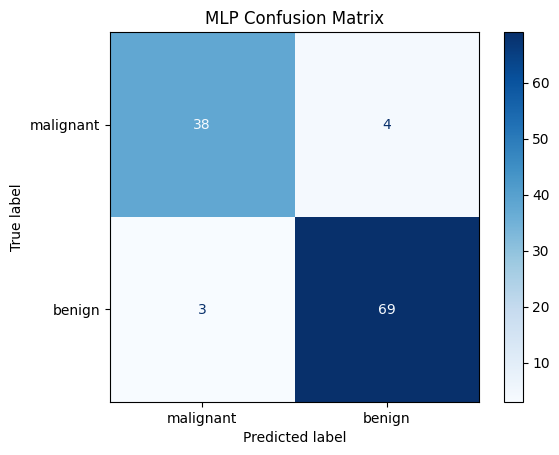

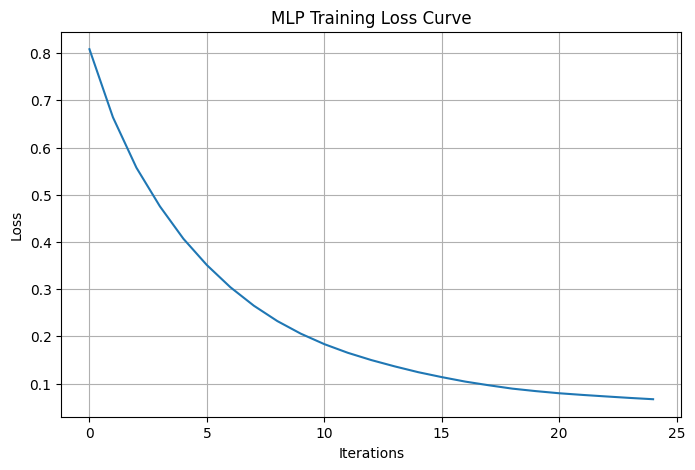

In [1]:
# Step 1: Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Step 2: Load the dataset

data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Target Classes:", data.target_names)

# Step 3: Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# Step 4: Create the MLP model with feature scaling

model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42,
        early_stopping=True
    ))
])

# Step 5: Train the model

model.fit(X_train, y_train)

# Step 6: Make predictions

y_pred = model.predict(X_test)

# Step 7: Evaluate the model

accuracy = accuracy_score(y_test, y_pred)

print("\nMLP Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

# Step 8: Display confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap="Blues")
plt.title("MLP Confusion Matrix")
plt.show()

# Step 9: Plot training loss curve

mlp_model = model.named_steps["mlp"]

plt.figure(figsize=(8, 5))
plt.plot(mlp_model.loss_curve_)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.grid(True)
plt.show()